In [2]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge , Lasso
from sklearn.metrics import r2_score, mean_absolute_error , mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

In [3]:
df = pd.read_csv("HousingData.csv")

In [4]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [5]:
df.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0.0,0.573,6.030,NaN,2.5050,1,273,21.0,396.90,7.88,11.9


# Lets explore about this dataset and it`s columns 

CRIM - Crime Rat


ZN-  Residential Area


INDUS- (Non-retail) business area proportion


CHAS - charles River


NOX - nitric oxide concentration


RM - avarage room


AGE - old house proportion


DIS - employment center


RAD - highway accessiblity index


TAX - property tax rate 


PTRATIO-  student & teacher ratio


B - Black population related value 


LSTAT-  lower status population value 


MEDV- median house value(Target Column)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In this dataset there are two types of datatype are present , int and float

In [7]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [8]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='str')

# Data Cleaning

In [9]:
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [10]:
df['CRIM'] = df['CRIM'].fillna(df['CRIM'].mean())
df['ZN'] = df['ZN'].fillna(df['ZN'].mean()) 
df['INDUS'] = df['INDUS'].fillna(df['INDUS'].mean()) 
df['CHAS'] = df['CHAS'].fillna(df['CHAS'].mean()) 
df['AGE'] = df['AGE'].fillna(df['AGE'].std()) 
df['LSTAT'] = df['LSTAT'].fillna(df['LSTAT'].median()) 

# EDA

<Axes: xlabel='MEDV', ylabel='CRIM'>

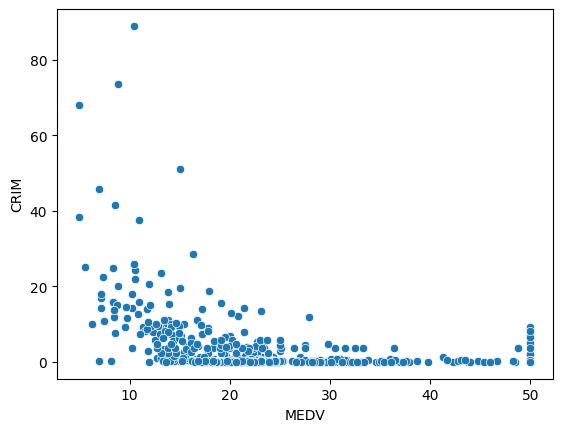

In [11]:
sns.scatterplot(x = df['MEDV'],y =  df['CRIM'])

<Axes: xlabel='RM', ylabel='MEDV'>

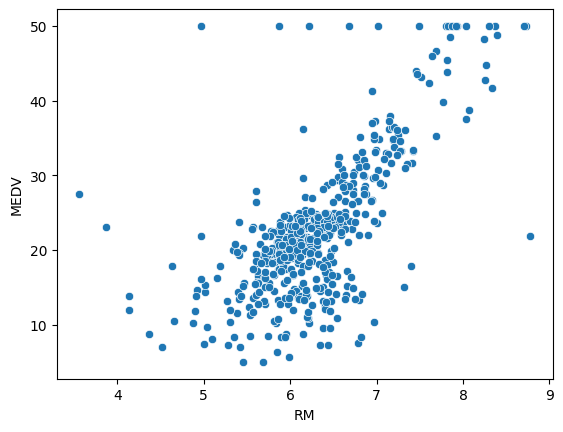

In [12]:
sns.scatterplot(x = df['RM'],y =  df['MEDV'])

<Axes: xlabel='TAX', ylabel='MEDV'>

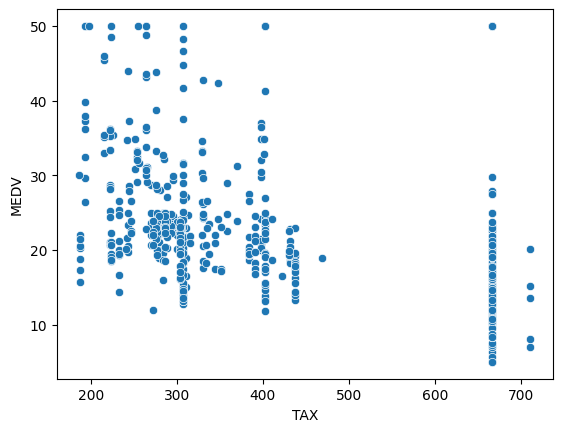

In [13]:
sns.scatterplot(x=df['TAX'], y=df['MEDV'])

<Axes: xlabel='LSTAT', ylabel='MEDV'>

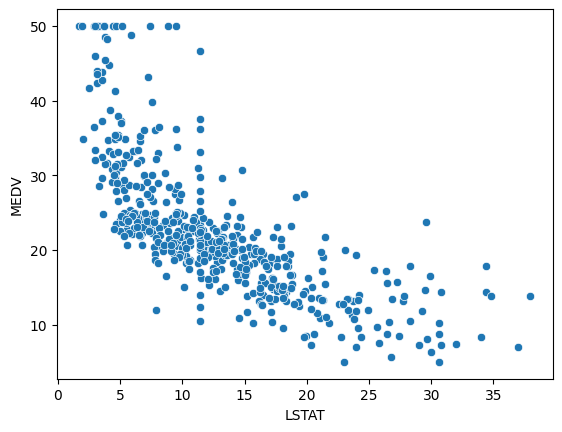

In [14]:
sns.scatterplot(x=df['LSTAT'], y=df['MEDV'])

<Axes: xlabel='MEDV', ylabel='Count'>

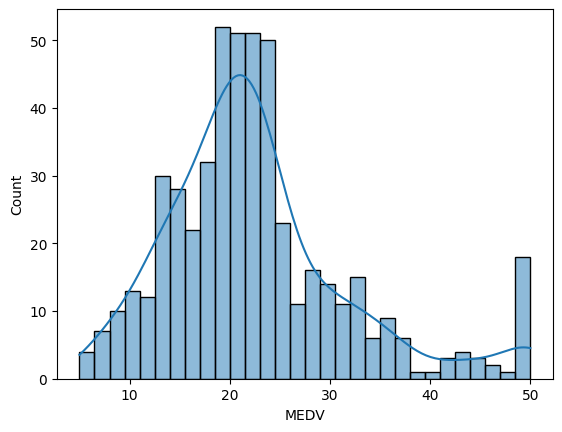

In [15]:
sns.histplot(df['MEDV'], bins=30, kde=True)

<Axes: xlabel='CHAS', ylabel='MEDV'>

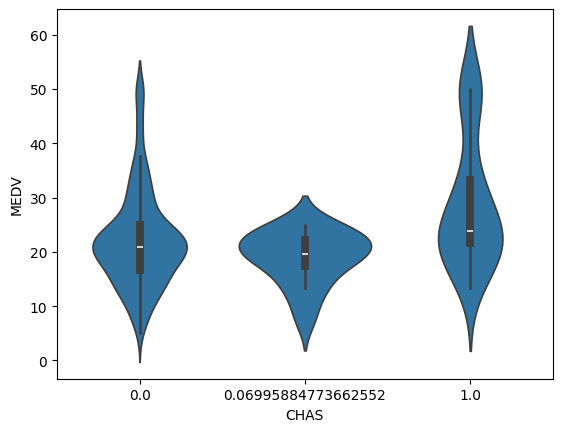

In [16]:
sns.violinplot(x=df['CHAS'], y=df['MEDV'])

<Axes: xlabel='MEDV', ylabel='Density'>

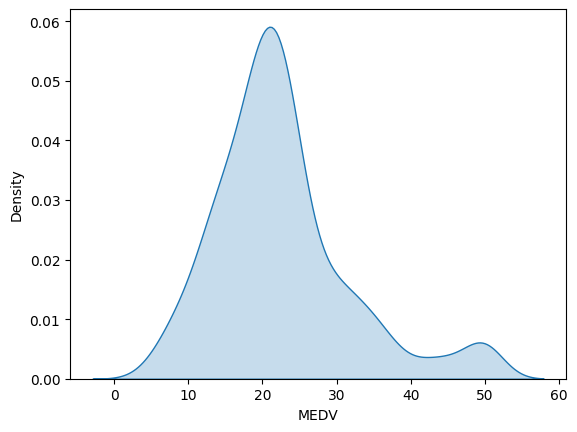

In [17]:
sns.kdeplot(df['MEDV'], fill=True)

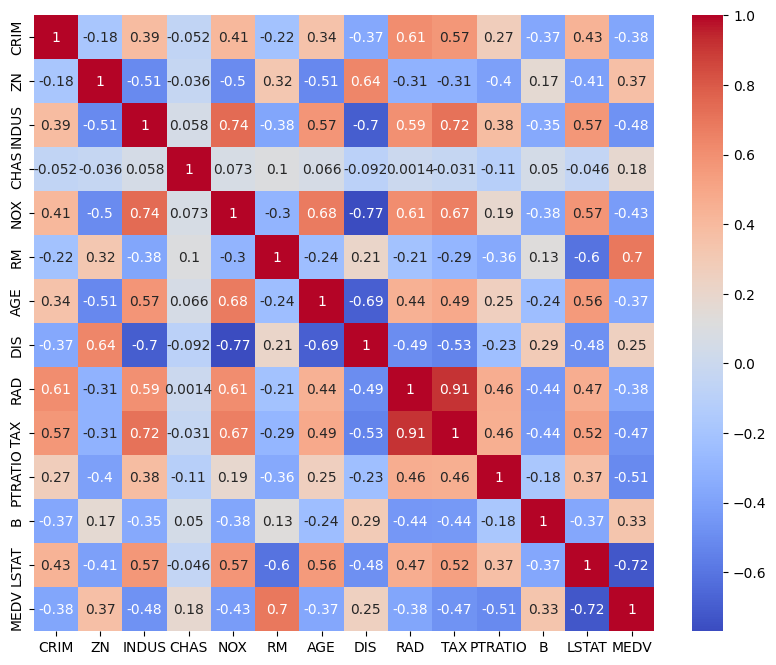

In [18]:
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# Data spliting

In [19]:
x = df.drop(['MEDV'], axis=1)
y = df['MEDV']

# Train-Test apply

In [20]:
x_train, x_test , y_train ,y_test = train_test_split(x,y, train_size=.8,random_state=400)

# Apply Scalling

In [21]:
sc = StandardScaler()
x= sc.fit_transform(x)

# Linear Regression apply and Model Evaluation

In [22]:
lr = LinearRegression()
# training 
model = lr.fit(x_train,y_train)
print("Trainig Score : ", model.score(x_train,y_train)*100)

# test
print("Test Score : ", model.score(x_test,y_test)*100)

# predicition
pred = lr.predict(x_test)


# R2 Score
r2_lr= r2_score(y_test, pred)

print("R2 Score :", r2_lr)

# MAE

mae = mean_absolute_error(y_test, pred)
print("MAE : ", mae)

# MSE 
mse = mean_squared_error(y_test, pred)
print("MSE : ", mse)

Trainig Score :  73.4065352784796
Test Score :  70.8476812656395
R2 Score : 0.708476812656395
MAE :  3.1995310823328804
MSE :  18.766416823905036


# Decision Tree Regressor and Model Evaluation

In [23]:
dt = DecisionTreeRegressor()
# training 
model_dt = dt.fit(x_train,y_train)
print("Trainig Score : ", model_dt.score(x_train,y_train)*100)

# test
print("Test Score : ", model_dt.score(x_test,y_test)*100)

# predicition
pred_dt = dt.predict(x_test)


# R2 Score
r2_dt = r2_score(y_test, pred_dt)

print("R2 Score :", r2_dt)

# MAE

mae = mean_absolute_error(y_test, pred_dt)
print("MAE : ", mae)

# MSE 
mse = mean_squared_error(y_test, pred_dt)
print("MSE : ", mse)

Trainig Score :  100.0
Test Score :  80.60207335451517
R2 Score : 0.8060207335451517
MAE :  2.6578431372549027
MSE :  12.487156862745096


# Random Forest Regressor and Model Evaluation

In [24]:
rf = RandomForestRegressor()
# training 
model_rf = rf.fit(x_train,y_train)
print("Trainig Score : ", model_rf.score(x_train,y_train)*100)

# test
print("Test Score : ", model_rf.score(x_test,y_test)*100)

# predicition
pred_rf = rf.predict(x_test)


# R2 Score
r2_rf = r2_score(y_test, pred_rf)

print("R2 Score :", r2_rf)

# MAE

mae = mean_absolute_error(y_test, pred_rf)
print("MAE : ", mae)

# MSE 
mse = mean_squared_error(y_test, pred_rf)
print("MSE : ", mse)

Trainig Score :  97.80560682939846
Test Score :  85.8754106251759
R2 Score : 0.8587541062517591
MAE :  2.1641666666666692
MSE :  9.092516245098052


# Support vector Regressor apply and model Evaluation

In [25]:
svr = SVR()

# training 
model_svr = svr.fit(x_train,y_train)
print("Trainig Score : ", model_svr.score(x_train,y_train)*100)

# test
print("Test Score : ", model_svr.score(x_test,y_test)*100)

# predicition
pred_svr = svr.predict(x_test)


# R2 Score
r2_svr= r2_score(y_test, pred_svr)

print("R2 Score :", r2_svr)

# MAE

mae = mean_absolute_error(y_test, pred_svr)
print("MAE : ", mae)

# MSE 
mse = mean_squared_error(y_test, pred_svr)
print("MSE : ", mse)

Trainig Score :  18.11035485200315
Test Score :  27.397484339513746
R2 Score : 0.27397484339513745
MAE :  4.745237663121273
MSE :  46.736902260295146


# Ridge Apply and Model Evaluation

In [26]:
ridge = Ridge(alpha=.01)

# training 
model_ridge= ridge.fit(x_train,y_train)
print("Trainig Score : ", model_ridge.score(x_train,y_train)*100)

# test
print("Test Score : ", model_ridge.score(x_test,y_test)*100)

# predicition
pred_ridge = ridge.predict(x_test)


# R2 Score
r2_ridge= r2_score(y_test, pred_ridge)

print("R2 Score :", r2_ridge)

# MAE

mae = mean_absolute_error(y_test, pred_ridge)
print("MAE : ", mae)

# MSE 
mse = mean_squared_error(y_test, pred_ridge)
print("MSE : ", mse)

Trainig Score :  73.40647856296596
Test Score :  70.84804605810216
R2 Score : 0.7084804605810215
MAE :  3.1992623309019326
MSE :  18.766181993616893


# Lasso Apply and Model Evaluation

In [27]:
lasso = Lasso(alpha = 0.01)

# training 
model_lasso= lasso.fit(x_train,y_train)
print("Trainig Score : ", model_lasso.score(x_train,y_train)*100)

# test
print("Test Score : ", model_lasso.score(x_test,y_test)*100)

# predicition
pred_lasso = lasso.predict(x_test)


# R2 Score
r2_lasso  = r2_score(y_test, pred_lasso)

print("R2 Score :", r2_lasso)

# MAE

mae = mean_absolute_error(y_test, pred_lasso)
print("MAE : ", mae)

# MSE 
mse = mean_squared_error(y_test, pred_lasso)
print("MSE : ", mse)

Trainig Score :  73.36920544348548
Test Score :  70.92095239098317
R2 Score : 0.7092095239098317
MAE :  3.1916000002566447
MSE :  18.719249513068274


# Best Model Selection for This Model

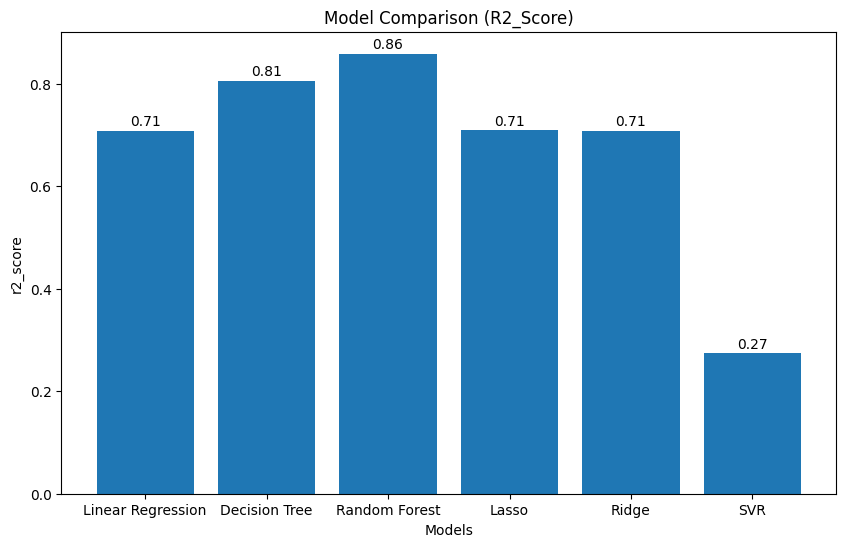

In [28]:
models = ['Linear Regression', 'Decision Tree', 'Random Forest' , 'Lasso','Ridge','SVR']
scores = [r2_lr,r2_dt,r2_rf,r2_lasso,r2_ridge,r2_svr]

# ====== Bar Chart ======
plt.figure(figsize=(10,6))

plt.bar(models, scores)

plt.xlabel("Models")
plt.ylabel("r2_score")
plt.title("Model Comparison (R2_Score)")

# show values on top
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()


In [29]:
import pickle
pickle.dump(model_rf,open('model_rf.pkl','wb'))